## Creating a sequential LangGraph

In [28]:
# Objectives of this workflow: 
# 1. Define the state of the BMI calculator
# 2. Define the function to calculate BMI
# 3. Create a workflow graph
# 4. Execute the graph

In [21]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


In [22]:
#define the state of the BMI calculator
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float

In [23]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    
    bmi = weight / (height ** 2)

    state['bmi'] = round(bmi, 2)
    return state

In [24]:
#define your graph
graph = StateGraph(BMIState)

# add nodes to the graph
graph.add_node('cal_bmi', calculate_bmi)

# add edges to the graph
graph.add_edge(START, 'cal_bmi')
graph.add_edge('cal_bmi', END)

# compile the graph
workflow = graph.compile()



In [25]:
# execute the graph
workflow.invoke({
    'weight_kg': 70,
    'height_m': 1.75
})

{'weight_kg': 70, 'height_m': 1.75, 'bmi': 22.86}

In [26]:
#Another way to execute the graph
initial_state = {
    'weight_kg': 70,
    'height_m': 1.75
}

final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 70, 'height_m': 1.75, 'bmi': 22.86}


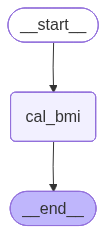

In [27]:
#How to see the graph structure

from IPython.display import display, Image

Image(workflow.get_graph().draw_mermaid_png())